In [1]:
from pathlib import Path
import sys, os
repo_root = os.path.abspath("..")
if repo_root not in sys.path:
    sys.path.append(repo_root)
from src.modeling_lgbm import run_lgbm_models

ROOT = Path(".").resolve().parents[0] if (Path(".") / "src").exists() else Path("..")
DATA_TRAIN = ROOT / "data" / "processed" / "training_fe_full.csv"
DATA_TEST = ROOT / "data" / "processed" / "test_fe_full.csv"
DATA_LABELS = ROOT / "data" / "raw" / "training_set_labels.csv"
ARTIFACTS = ROOT / "artifacts_lgbm"

In [2]:

results_lgbm = run_lgbm_models(
    train_features_path=str(DATA_TRAIN),
    test_features_path=str(DATA_TEST),
    train_labels_path=str(DATA_LABELS),
    n_splits=5,
    out_dir=str(ARTIFACTS),
)

Running fold 1/5 for h1n1_vaccine...
Running fold 2/5 for h1n1_vaccine...
Running fold 3/5 for h1n1_vaccine...
Running fold 4/5 for h1n1_vaccine...
Running fold 5/5 for h1n1_vaccine...

h1n1_vaccine CV results: accuracy=0.856, precision=0.733, recall=0.509, f1=0.601, roc_auc=0.871
Running fold 1/5 for seasonal_vaccine...
Running fold 2/5 for seasonal_vaccine...
Running fold 3/5 for seasonal_vaccine...
Running fold 4/5 for seasonal_vaccine...
Running fold 5/5 for seasonal_vaccine...

seasonal_vaccine CV results: accuracy=0.786, precision=0.777, recall=0.759, f1=0.768, roc_auc=0.863

=== Summary (Macro F1) ===
h1n1_vaccine        : 0.601
seasonal_vaccine    : 0.768
Overall macro F1: 0.684


| Target       |       F1 | ROC-AUC | Comment                                              |
| :----------- | -------: | ------: | :--------------------------------------------------- |
| **H1N1**     |     0.60 |    0.87 | Harder label, class imbalance → precision-recall gap |
| **Seasonal** |     0.77 |    0.86 | Very strong baseline already                         |
| **Macro F1** | **0.68** |       — | Matches logistic baseline → solid foundation         |


In [3]:
# ==========================================
# LightGBM Hyperparameter Tuning
# ==========================================
import lightgbm as lgb
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score

# ------------------------
# Data paths
# ------------------------
ROOT = Path(".").resolve().parents[0] if (Path(".") / "src").exists() else Path("..")
DATA_TRAIN = ROOT / "data" / "processed" / "training_fe_full.csv"
DATA_TEST = ROOT / "data" / "processed" / "test_fe_full.csv"
DATA_LABELS = ROOT / "data" / "raw" / "training_set_labels.csv"

# ------------------------
# Load & prepare
# ------------------------
TARGET_COLS = ["h1n1_vaccine", "seasonal_vaccine"]

train = pd.read_csv(DATA_TRAIN).drop(columns=[c for c in ["Unnamed: 0", "respondent_id"] if c in pd.read_csv(DATA_TRAIN).columns])
labels = pd.read_csv(DATA_LABELS)[TARGET_COLS].astype(int)

# Clean column names for LightGBM
import re
train.columns = [re.sub(r'[^A-Za-z0-9_]', '_', c) for c in train.columns]

# ------------------------
# Define model and param grid
# ------------------------
model = lgb.LGBMClassifier(
    objective="binary",
    metric="auc",
    boosting_type="gbdt",
    random_state=42,
    n_estimators=1000,
)

param_grid = {
    "num_leaves": [15, 31, 63],
    "max_depth": [4, 6, 8, -1],
    "learning_rate": [0.01, 0.03, 0.05],
    "feature_fraction": [0.7, 0.8, 0.9, 1.0],
    "bagging_fraction": [0.7, 0.8, 0.9, 1.0],
    "lambda_l1": [0.0, 0.5, 1.0],
    "lambda_l2": [0.0, 0.5, 1.0],
    "min_data_in_leaf": [20, 50, 100],
}

# For faster search, we’ll use random search (can switch to GridSearchCV)
searcher = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    scoring=make_scorer(f1_score),
    n_iter=25,                # number of random parameter combinations
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    verbose=1,
    n_jobs=-1,
    random_state=42,
)

# ------------------------
# Run tuning separately for each label
# ------------------------
best_params = {}

for target in TARGET_COLS:
    print(f"\n=== Tuning for {target} ===")
    X = train.copy()
    y = labels[target]

    searcher.fit(X, y)

    print(f"Best F1 for {target}: {searcher.best_score_:.4f}")
    print("Best Params:")
    for k, v in searcher.best_params_.items():
        print(f"  {k}: {v}")

    best_params[target] = {
        "f1": searcher.best_score_,
        "params": searcher.best_params_,
    }

# ------------------------
# Summary
# ------------------------
print("\n=== Final best parameter summary ===")
for target, res in best_params.items():
    print(f"{target:20s}: F1={res['f1']:.4f} | Params={res['params']}")



=== Tuning for h1n1_vaccine ===
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best F1 for h1n1_vaccine: 0.6059
Best Params:
  num_leaves: 31
  min_data_in_leaf: 20
  max_depth: 6
  learning_rate: 0.01
  lambda_l2: 1.0
  lambda_l1: 1.0
  feature_fraction: 0.8
  bagging_fraction: 0.8

=== Tuning for seasonal_vaccine ===
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best F1 for seasonal_vaccine: 0.7668
Best Params:
  num_leaves: 31
  min_data_in_leaf: 100
  max_depth: 4
  learning_rate: 0.01
  lambda_l2: 0.0
  lambda_l1: 0.5
  feature_fraction: 0.8
  bagging_fraction: 0.8

=== Final best parameter summary ===
h1n1_vaccine        : F1=0.6059 | Params={'num_leaves': 31, 'min_data_in_leaf': 20, 'max_depth': 6, 'learning_rate': 0.01, 'lambda_l2': 1.0, 'lambda_l1': 1.0, 'feature_fraction': 0.8, 'bagging_fraction': 0.8}
seasonal_vaccine    : F1=0.7668 | Params={'num_leaves': 31, 'min_data_in_leaf': 100, 'max_depth': 4, 'learning_rate': 0.01, 'lambda_l2': 0.0, 'lam

In [4]:
import json
from pathlib import Path

# Directory to store the results
SAVE_DIR = ROOT / "artifacts_lgbm_tuning"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

for target, res in best_params.items():
    file_path = SAVE_DIR / f"best_params_{target}.json"
    with open(file_path, "w", encoding="utf-8") as f:
        json.dump(res["params"], f, indent=2)
    print(f"Saved best params for {target} → {file_path}")

# Optionally: save a combined summary
summary_path = SAVE_DIR / "lgbm_best_params_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(best_params, f, indent=2)

print(f"\nAll parameter summaries saved to {summary_path}")


Saved best params for h1n1_vaccine → ..\artifacts_lgbm_tuning\best_params_h1n1_vaccine.json
Saved best params for seasonal_vaccine → ..\artifacts_lgbm_tuning\best_params_seasonal_vaccine.json

All parameter summaries saved to ..\artifacts_lgbm_tuning\lgbm_best_params_summary.json


Running fold 1/5 for H1N1 Vaccine...
Fold 1: Train F1=0.655 | Val F1=0.588
Running fold 2/5 for H1N1 Vaccine...
Fold 2: Train F1=0.667 | Val F1=0.612
Running fold 3/5 for H1N1 Vaccine...
Fold 3: Train F1=0.653 | Val F1=0.602
Running fold 4/5 for H1N1 Vaccine...
Fold 4: Train F1=0.665 | Val F1=0.601
Running fold 5/5 for H1N1 Vaccine...
Fold 5: Train F1=0.665 | Val F1=0.594

=== H1N1 Vaccine CV Summary ===
Train F1: 0.661 | Val F1: 0.600 | Gap: 0.061
Running fold 1/5 for Seasonal Vaccine...
Fold 1: Train F1=0.805 | Val F1=0.775
Running fold 2/5 for Seasonal Vaccine...
Fold 2: Train F1=0.810 | Val F1=0.766
Running fold 3/5 for Seasonal Vaccine...
Fold 3: Train F1=0.801 | Val F1=0.775
Running fold 4/5 for Seasonal Vaccine...
Fold 4: Train F1=0.803 | Val F1=0.763
Running fold 5/5 for Seasonal Vaccine...
Fold 5: Train F1=0.806 | Val F1=0.770

=== Seasonal Vaccine CV Summary ===
Train F1: 0.805 | Val F1: 0.770 | Gap: 0.035


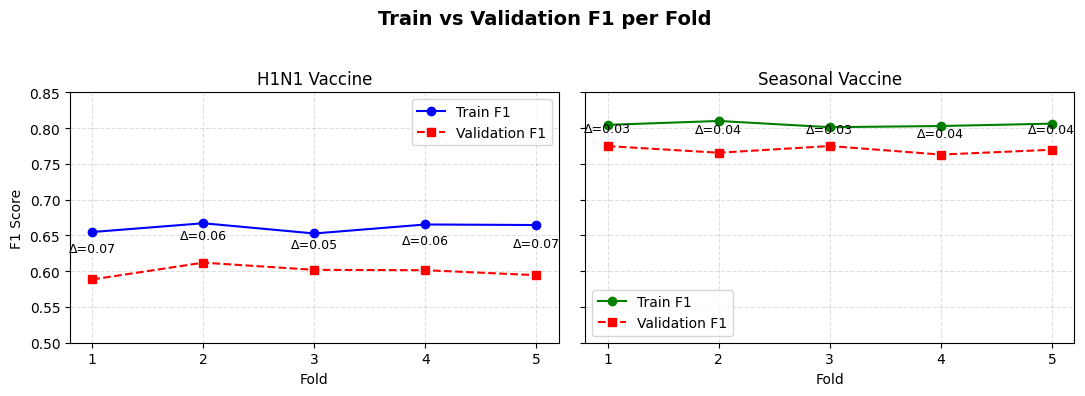

✅ Comparison plot with annotations saved to: ..\artifacts_lgbm\train_val_f1_comparison.png
Average gaps: H1N1=0.061, Seasonal=0.035


In [3]:
from src.modeling_lgbm import lgbm_cv_with_train_eval, clean_feature_names
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# -------------------------------------------------------
# 1. Load data
# -------------------------------------------------------
ROOT = Path(".").resolve().parents[0] if (Path(".") / "src").exists() else Path("..")
DATA_TRAIN = ROOT / "data" / "processed" / "training_fe_full.csv"
DATA_LABELS = ROOT / "data" / "raw" / "training_set_labels.csv"
ARTIFACTS = ROOT / "artifacts_lgbm"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

X = pd.read_csv(DATA_TRAIN)
y_all = pd.read_csv(DATA_LABELS)[["h1n1_vaccine", "seasonal_vaccine"]].astype(int)
X = clean_feature_names(X)

# -------------------------------------------------------
# 2. Run CV for both labels
# -------------------------------------------------------
res_h1n1 = lgbm_cv_with_train_eval(X, y_all["h1n1_vaccine"], label_name="H1N1 Vaccine", plot=False)
res_seas = lgbm_cv_with_train_eval(X, y_all["seasonal_vaccine"], label_name="Seasonal Vaccine", plot=False)

# -------------------------------------------------------
# 3. Plot: Train vs Validation F1 per fold
# -------------------------------------------------------
folds = np.arange(1, len(res_h1n1["train_f1_per_fold"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
plt.suptitle("Train vs Validation F1 per Fold", fontsize=14, weight="bold")

for ax, res, title, color in zip(
    axes,
    [res_h1n1, res_seas],
    ["H1N1 Vaccine", "Seasonal Vaccine"],
    ["blue", "green"],
):
    ax.plot(folds, res["train_f1_per_fold"], marker="o", label="Train F1", color=color)
    ax.plot(folds, res["val_f1_per_fold"], marker="s", label="Validation F1", color="red", linestyle="--")

    # Annotate gap above folds
    for i, (tr, va) in enumerate(zip(res["train_f1_per_fold"], res["val_f1_per_fold"])):
        ax.text(
            folds[i],
            (tr + va) / 2 + 0.005,
            f"Δ={tr - va:.02f}",
            ha="center",
            fontsize=9,
            color="black",
        )

    ax.set_title(title)
    ax.set_xlabel("Fold")
    ax.set_xticks(folds)
    ax.grid(alpha=0.4, linestyle="--")
    ax.legend()
    ax.set_ylim(0.5, 0.85)

axes[0].set_ylabel("F1 Score")
plt.tight_layout(rect=[0, 0, 1, 0.95])

# -------------------------------------------------------
# 4. Save and display
# -------------------------------------------------------
plot_path = ARTIFACTS / "train_val_f1_comparison.png"
plt.savefig(plot_path, dpi=200)
plt.show()

print(f"✅ Comparison plot with annotations saved to: {plot_path}")
print(f"Average gaps: H1N1={res_h1n1['gap']:.3f}, Seasonal={res_seas['gap']:.3f}")


### LightGBM Cross-Validation Results

We performed 5-fold cross-validation for both **H1N1 Vaccine** and **Seasonal Vaccine** models, comparing **training and validation F1 scores** to assess model generalization.

#### H1N1 Vaccine
| Metric | Mean |
|:--|:--|
| Train F1 | **0.661** |
| Validation F1 | **0.600** |
| Gap (Train − Val) | **0.061** |

- The small F1 gap (~0.06) indicates **minimal overfitting** and a well-regularized model.  
- Both training and validation scores are moderate, suggesting **mild underfitting**, which is acceptable given the higher difficulty and class imbalance of the H1N1 target.

#### Seasonal Vaccine
| Metric | Mean |
|:--|:--|
| Train F1 | **0.805** |
| Validation F1 | **0.770** |
| Gap (Train − Val) | **0.035** |

- The Seasonal Vaccine model achieves **higher and more stable performance** across folds.  
- The F1 gap (~0.04) confirms excellent **generalization** and low variance across splits.  
- Validation scores are consistently high (~0.77), demonstrating strong predictive power.

#### Overall Interpretation
- Both models show healthy generalization behavior, with no sign of significant overfitting.  
- The H1N1 task remains more challenging due to lower vaccination rates and higher class imbalance.  
- The Seasonal Vaccine model, in contrast, captures population-level behavioral and demographic patterns more effectively.